## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [1]:
import pandas as pd

path=r"C:\Users\smart\OneDrive\Documents\Semester 10\bank+marketing\bank\bank-full.csv"
df = pd.read_csv(path, sep=";")

print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [2]:
#Identify Numeric vs Categorical Features
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')
Categorical: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


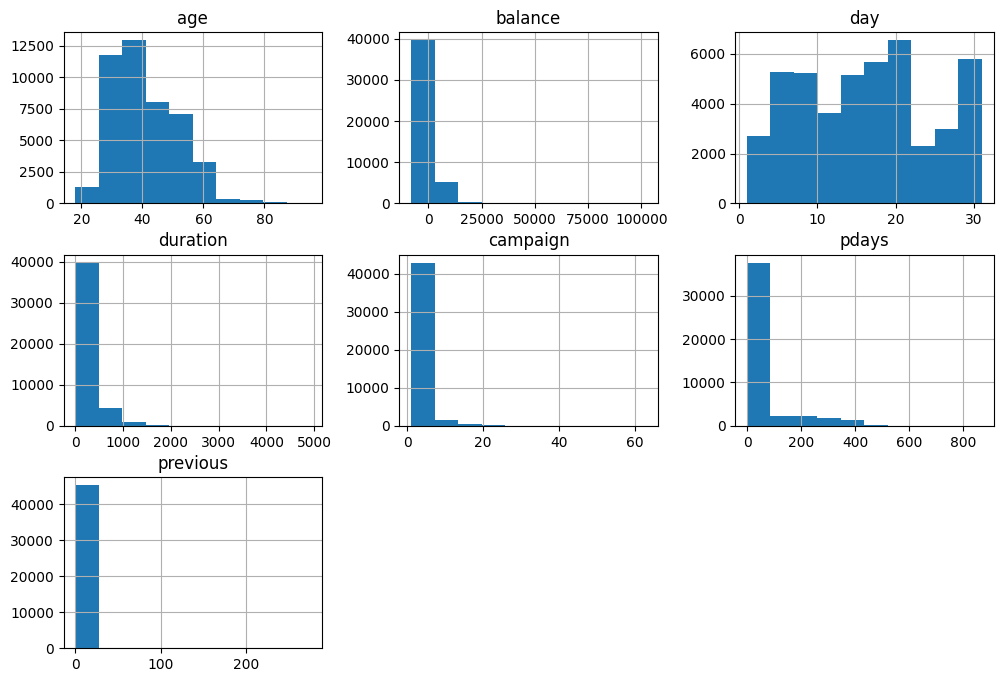

In [3]:
#Distribution of Numeric Features
df[numeric_cols].describe()
df[numeric_cols].skew()

import matplotlib.pyplot as plt

df[numeric_cols].hist(figsize=(12,8))
plt.show()

#The plots showed a skewed distributions

In [4]:
#Counts of Categories
for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())



 job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

 marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

 education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

 default
default
no     44396
yes      815
Name: count, dtype: int64

 housing
housing
yes    25130
no     20081
Name: count, dtype: int64

 loan
loan
no     37967
yes     7244
Name: count, dtype: int64

 contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

 month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Nam

In [5]:
#Missing or Unknown Values
#First trial with errors (Handling all as one thing!!)
# df.isnull().sum()
# (df == "unknown").sum()

# #Since the distributions are skewed, we will use median to fill the missing values
# for col in numeric_cols:
#     df[col].fillna(df[col].median(), inplace=True)

#Second trial
import numpy as np

# 1️⃣ Convert "unknown" → NaN
df.replace("unknown", np.nan, inplace=True)

# 2️⃣ Fill numeric missing values with median
for col in numeric_cols:
   df[col] = df[col].fillna(df[col].median())

# 3️⃣ Fill categorical missing values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    

# 4️⃣ Handle special case column
df["pdays"] = df["pdays"].replace(999, -1)   


               age   balance       day  duration  campaign     pdays  previous
age       1.000000  0.097783 -0.009120 -0.004648  0.004760 -0.023758  0.001288
balance   0.097783  1.000000  0.004503  0.021560 -0.014578  0.003435  0.016674
day      -0.009120  0.004503  1.000000 -0.030206  0.162490 -0.093044 -0.051710
duration -0.004648  0.021560 -0.030206  1.000000 -0.084570 -0.001565  0.001203
campaign  0.004760 -0.014578  0.162490 -0.084570  1.000000 -0.088628 -0.032855
pdays    -0.023758  0.003435 -0.093044 -0.001565 -0.088628  1.000000  0.454820
previous  0.001288  0.016674 -0.051710  0.001203 -0.032855  0.454820  1.000000


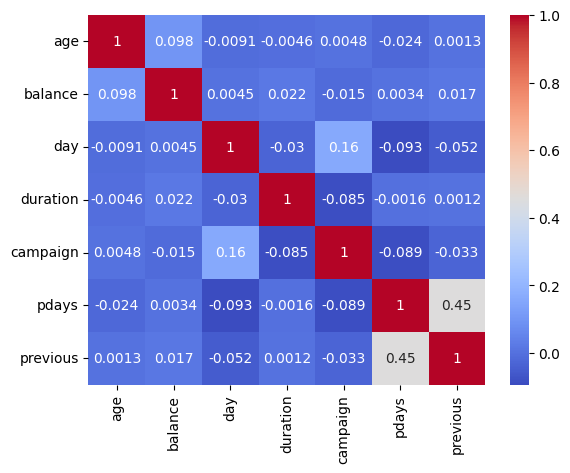

In [6]:
#Correlation Between Numeric Features
corr = df[numeric_cols].corr()
print(corr)

#For visualization 
import seaborn as sns

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

#The observation was that the features are not correlated which can help us with clustering

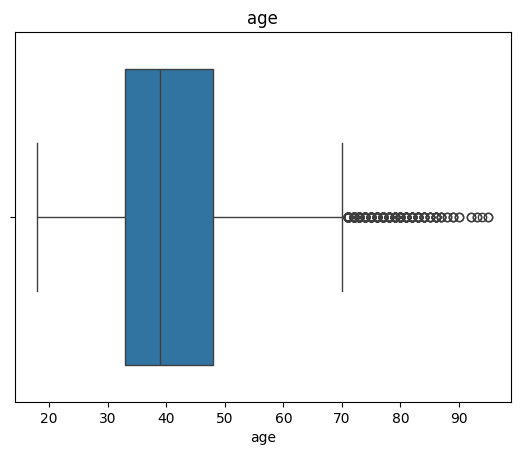

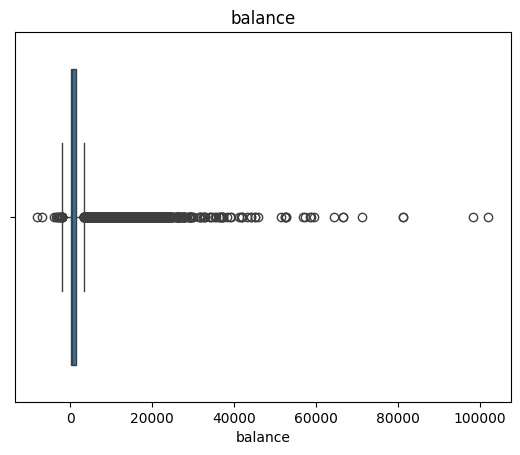

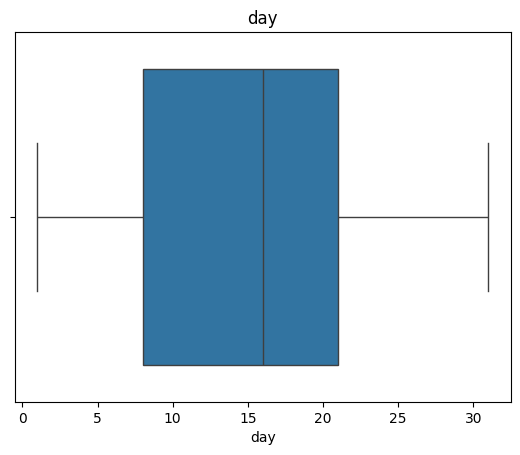

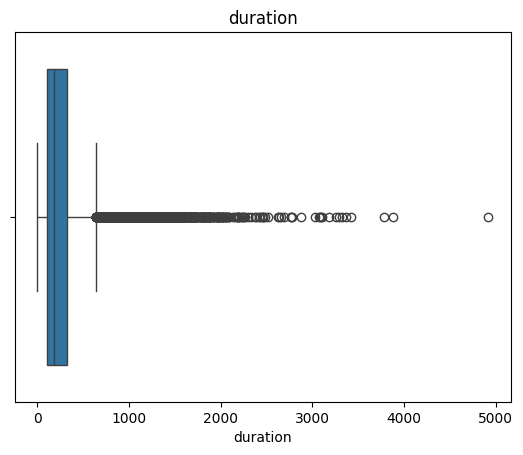

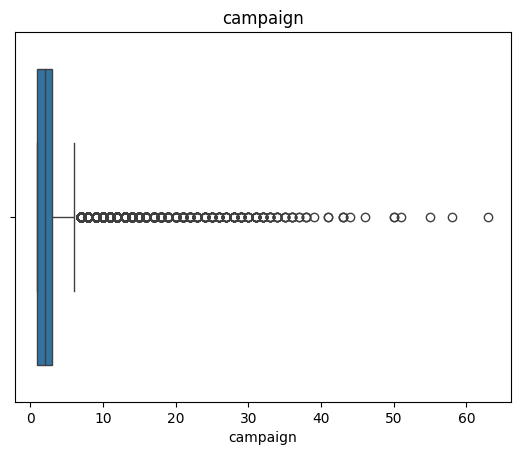

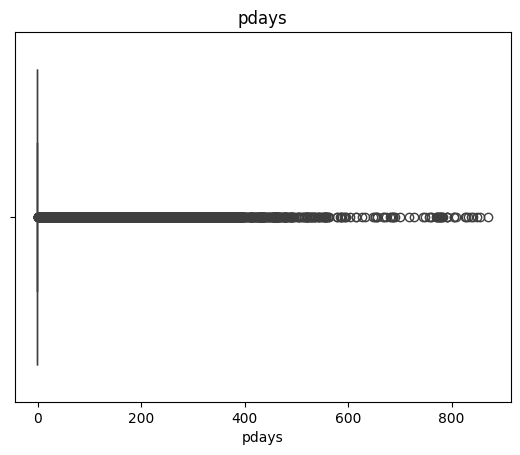

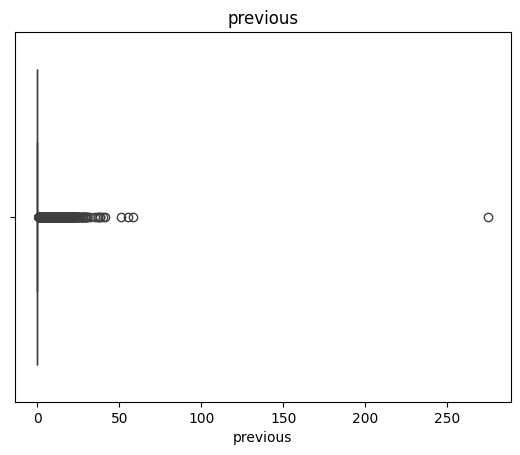

In [7]:
#Outliers
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

In [8]:
#Dropping (According to what??)
df_model = df.copy()

# drop target column (we don't use labels in clustering)
df_model.drop("y", axis=1, inplace=True)

In [9]:
#Encoding
from sklearn.preprocessing import  StandardScaler

# one-hot encode categorical variables
df_model = pd.get_dummies(df_model, drop_first=True)

In [10]:
#Scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)

In [11]:
#Final check on the dataset after data prepration
print("Missing values:\n", pd.DataFrame(df_scaled).isnull().sum().sum())
print("Shape:", df_scaled.shape)
print("Data type:", type(df_scaled))

Missing values:
 0
Shape: (45211, 38)
Data type: <class 'numpy.ndarray'>


### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

In [12]:
#Number of clusters
k=3  #small & Safe & easy to visualize

#K-means Model
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_scaled)

KMeans(n_clusters=3, random_state=42)

In [13]:
#Assigning
clusters = kmeans.labels_
df_model["Cluster"] = clusters

#To see cluster distribution
df_model["Cluster"].value_counts()


Cluster
1    30923
0    13473
2      815
Name: count, dtype: int64

### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

[-96696.53766697 -44491.0689086  -47306.37036832 -46588.97874173
 -45696.15581646 -47282.88638129 -35162.44060742 -45922.4230996
 -43247.78579702]


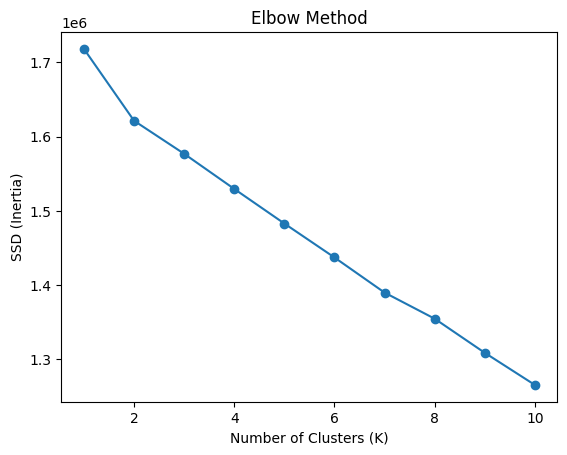

In [16]:
#Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ssd = []
K_range = range(1,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    ssd.append(kmeans.inertia_)

#Computing the rate of change to easily detect the elbow point 
diffs = np.diff(ssd)
print(diffs)   

# plot
plt.plot(K_range, ssd, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSD (Inertia)")
plt.title("Elbow Method")
plt.show()

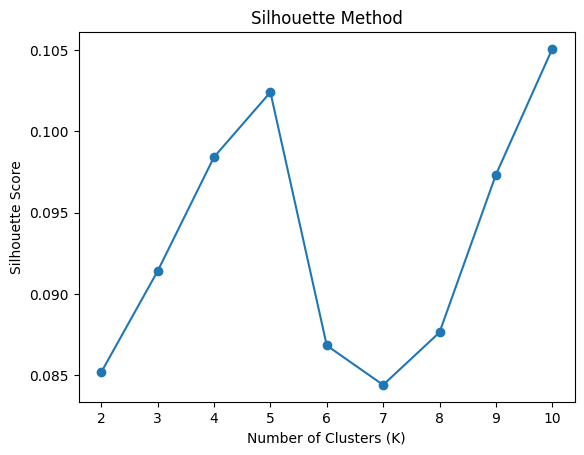

In [17]:
#Silhouette scores
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    scores.append(score)

# plot
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()